We will adapt the approach used [here](https://github.com/Armanfard-Lab/AADSCL#) to the teacher-student architecture of DINO.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/ASD-with-SSL/data/-6_dB_fan.zip" /content/-6_dB_fan.zip
!unzip -q /content/-6_dB_fan.zip -d /content/data

In [12]:
import random
from pathlib import Path

import numpy as np
import os
import copy
import pandas as pd
import soundfile as sf
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, ConcatDataset

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

DATA_ROOT = Path('data/fan')
SAVE_DIR = Path('/content/drive/MyDrive/ASD-with-SSL') #Change this to wherever you want to save the model weights in your Drive

MACHINE = 'fan'
MACHINE_IDS = [0,2,4,6]

PRETRAIN = True #Change if you're using pretrained weights

Using device: cuda


In [13]:
class MIMII(Dataset):
    def __init__(self, data_dir, labels):
        self.labels = labels
        self.data_dir = data_dir

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        path = self.data_dir[idx]
        # Read with soundfile (this torchaudio build requires torchcodec for
        # torchaudio.load, which isn't installed). soundfile returns (T, C).
        x, sr = sf.read(path, dtype='float32', always_2d=True)
        if x.size == 0:
            raise ValueError(f"Empty audio file: {path}")
        x = torch.from_numpy(x).mean(dim=1)  # mix down to mono -> (T,)
        y = self.labels[idx]
        return x, y

def audiodir(machine, id=0, Data='normal'):
  '''
  Find the audio directory
  Inputs:
  machine: Name of the machine (valve/slider/fan/pump)
  id: ID of the machine (0,2,4,6)

  Outputs:
  dir: List of data addresses
  label: List of labels (0 -> normal, 1 -> abnormal)
  '''

  # Support both structures: machine/id_XX/normal and machine/normal
  id_dir = os.path.join('data',machine, 'id_' + str(format(id, '02d')))
  flat_dir = os.path.join(machine)

  if os.path.isdir(id_dir):
    normaldir = os.path.join(id_dir, 'normal')
    abnormaldir = os.path.join(id_dir, 'abnormal')
  else:
    normaldir = os.path.join('data',flat_dir, 'normal')
    abnormaldir = os.path.join('data',flat_dir, 'abnormal')

  if not os.path.isdir(normaldir):
    raise FileNotFoundError(f"Normal data directory not found: {normaldir}")
  if not os.path.isdir(abnormaldir):
    raise FileNotFoundError(f"Abnormal data directory not found: {abnormaldir}")

  dirs = []
  label = []
  if Data == 'normal':
    file_list = sorted(os.listdir(normaldir))
    for i in file_list:
      if i.endswith('.wav'):
        dir_address = os.path.join(normaldir, i)
        dirs.append(dir_address)
        label.append(0)
  else:
    file_list = sorted(os.listdir(abnormaldir))
    for i in file_list:
      if i.endswith('.wav'):
        dir_address = os.path.join(abnormaldir, i)
        dirs.append(dir_address)
        label.append(1)

  return dirs, label

def train_test(machine='Pump', id=0, train_size=0.75, num_workers=0 ,verbosity = 1):
  # num_workers=0 keeps data loading in the main process. In a notebook on
  # Python 3.14 (default 'forkserver' start method) using workers makes them
  # re-import the notebook-defined `MIMII` class, which fails with
  # "module '__main__' has no attribute 'MIMII'". Set >0 only if MIMII lives
  # in an importable .py module.
  dir_normal, label_normal = audiodir(machine, id)
  dir_abnormal, label_abnormal = audiodir(machine, id, Data='abnormal')

  dataset_normal = MIMII(dir_normal, label_normal)
  dataset_abnormal = MIMII(dir_abnormal, label_abnormal)

  n_train = int(len(dataset_normal) * train_size)
  n_test = len(dataset_normal) - n_train
  train_dataset, test_normal_dataset = torch.utils.data.random_split(
      dataset_normal, [n_train, n_test]
  )

  test_dataset = ConcatDataset([test_normal_dataset, dataset_abnormal])

  Train = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=num_workers, drop_last=True)
  Test = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=num_workers)

  if verbosity > 0:
    print(f"Machine: {machine}, ID: {id}")
    print(f"  Normal samples: {len(dataset_normal)} (train: {n_train}, test: {n_test})")
    print(f"  Abnormal samples: {len(dataset_abnormal)}")
    print(f"  Total test: {len(test_dataset)}")

  return Train, Test

## DINO self-supervised adaptation

We convert the AADSCL supervised-contrastive setup into DINO self-distillation:

- **Student + Teacher** share the architecture (ResNet-18 backbone + `DINOHead`). The teacher is an EMA copy of the student and receives no gradients.
- **No labels and no negatives.** The loss is the cross-entropy between the teacher's (sharpened, centered) output distribution and the student's. Collapse is prevented by teacher centering + temperature sharpening + stop-gradient.
- **Multi-crop.** From each clip's log-mel spectrogram we take 2 *global* time-crops and several *local* time-crops. The teacher sees only the global crops; the student sees all of them.
- `apply_transform` is the per-crop augmentation (SpecAugment-style freq/time masking + noise). The classifier `CLS` is no longer part of training and is kept only as a downstream linear probe.

In [14]:
import torchaudio
import torchvision
import torchaudio.transforms as AT
import torchvision.transforms as VT
import torch.nn.functional as F
from torchvision.models import resnet18 as _resnet18
import random
import torch
import torch.nn as nn

device = DEVICE  # cell 1 defines DEVICE; trainer code below uses lowercase `device`

# ----- audio feature config -----
SAMPLE_RATE = 16000
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128
FIXED_FRAMES = 128  # all crops are resized to this width before the backbone

mel_extractor = AT.MelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)
amp_to_db = AT.AmplitudeToDB(stype='power', top_db=80).to(device)

# SpecAugment masks (operate on the (B, 1, mel, frame) tensor)
# freq_mask intentionally disabled: crops are now frequency-bands, so masking
# frequency bins would blank out the very signal the crops are meant to compare.
freq_mask = AT.FrequencyMasking(freq_mask_param=24)
time_mask = AT.TimeMasking(time_mask_param=24)
# Additional augmentation: Randomly erases rectangular patches
random_erasing = VT.RandomErasing(p=0.5, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0)


def make_resnet18():
    """ResNet-18 adapted to single-channel spectrograms; outputs 512-d features."""
    m = _resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc = nn.Identity()
    return m

BACKBONE_DIM = 512


def to_logmel(waveform):
    """(B, T) raw audio -> per-sample-normalized log-mel (B, 1, N_MELS, frames)."""
    spec = mel_extractor(waveform)        # (B, N_MELS, frames)
    spec = amp_to_db(spec).unsqueeze(1)   # (B, 1, N_MELS, frames)
    mean = spec.mean(dim=(2, 3), keepdim=True)
    std = spec.std(dim=(2, 3), keepdim=True) + 1e-5
    return (spec - mean) / std


def apply_transform(spec, train=True, use_extra_augs=False):
    """Per-crop augmentation on a log-mel spectrogram (B, 1, mel, frame)."""
    if not train:
        return spec

    # Standard SpecAugment (frequency masking disabled for frequency-band crops)
    # spec = freq_mask(spec)
    spec = time_mask(spec)
    if random.random() < 0.5:
        spec = spec + 0.05 * torch.randn_like(spec)

    # Optional Extra Augmentations
    if use_extra_augs:
        # Block Cutout (Random Erasing)
        spec = random_erasing(spec)

        # Random Amplitude/Gain Shift (simulates volume changes in the log domain)
        if random.random() < 0.5:
            # Random shift between -5 and +5 dB approx
            shift = (torch.rand(spec.shape[0], 1, 1, 1, device=spec.device) - 0.5) * 10.0
            spec = spec + shift

    return spec


def _rand_freq_crop(spec, height):
    """Crop a contiguous band of `height` mel bins (the frequency axis, dim -2)."""
    Mf = spec.shape[-2]
    if height >= Mf:
        return spec
    start = random.randint(0, Mf - height)
    return spec[..., start:start + height, :]


def multi_crop(waveform, n_global=2, n_local=6,
               global_frac=0.6, local_frac=0.25, train=True, use_extra_augs=False):
    """(B, T) raw audio -> list of augmented, equal-sized spectrogram crops.
    The first `n_global` entries are the global crops (fed to the teacher).
    Crops are taken along the mel-frequency axis, so each crop sees a different
    frequency band (the anomaly-bearing structure) over the full clip duration."""
    spec = to_logmel(waveform.to(device))     # (B, 1, N_MELS, Tt)
    Mf = spec.shape[-2]
    g, l = max(1, int(Mf * global_frac)), max(1, int(Mf * local_frac))
    crops = [_rand_freq_crop(spec, g) for _ in range(n_global)]
    crops += [_rand_freq_crop(spec, l) for _ in range(n_local)]
    crops = [F.interpolate(c, size=(N_MELS, FIXED_FRAMES),
                           mode='bilinear', align_corners=False) for c in crops]
    return [apply_transform(c, train=train, use_extra_augs=use_extra_augs) for c in crops]

In [15]:
class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim=1024, hidden_dim=512, bottleneck_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )

        self.last_layer = nn.Linear(bottleneck_dim, out_dim, bias=False)
        nn.utils.parametrizations.weight_norm(self.last_layer, name='weight')

        self.last_layer.parametrizations.weight.original0.data.fill_(1)
        self.last_layer.parametrizations.weight.original0.requires_grad = False  # freeze norm for stability

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)


class MultiCropWrapper(nn.Module):
    """Runs backbone+head over a list of crops, batching equal-shaped crops
    into a single forward pass (as in the original DINO)."""
    def __init__(self, backbone, head):
        super().__init__()
        self.backbone = backbone
        self.head = head

    def forward(self, crops):
        if not isinstance(crops, (list, tuple)):
            crops = [crops]
        idx_splits = [0]
        for i in range(1, len(crops)):
            if crops[i].shape[-1] != crops[i - 1].shape[-1]:
                idx_splits.append(i)
        idx_splits.append(len(crops))
        out = []
        for s, e in zip(idx_splits[:-1], idx_splits[1:]):
            out.append(self.backbone(torch.cat(crops[s:e])))
        return self.head(torch.cat(out))


class DINOLoss(nn.Module):
    def __init__(self, out_dim, teacher_temp=0.04, student_temp=0.1,
                 center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer("center", torch.zeros(1, out_dim))

    def forward(self, student_out, teacher_out, n_student_crops, n_teacher_crops):
        student = (student_out / self.student_temp).chunk(n_student_crops)
        teacher = F.softmax((teacher_out - self.center) / self.teacher_temp, dim=-1)
        teacher = teacher.detach().chunk(n_teacher_crops)

        total, n_terms = 0.0, 0
        for iq, q in enumerate(teacher):           # teacher (global) crops
            for iv, v in enumerate(student):       # all student crops
                if iv == iq:
                    continue                       # skip identical crop pair
                total += torch.sum(-q * F.log_softmax(v, dim=-1), dim=-1).mean()
                n_terms += 1
        self.update_center(teacher_out)
        return total / n_terms

    @torch.no_grad()
    def update_center(self, teacher_out):
        batch_center = teacher_out.mean(dim=0, keepdim=True)
        self.center.mul_(self.center_momentum).add_(
            batch_center * (1 - self.center_momentum))


@torch.no_grad()
def ema_update(student, teacher, m):
    for ps, pt in zip(student.parameters(), teacher.parameters()):
        pt.data.mul_(m).add_(ps.detach().data, alpha=1 - m)


In [16]:
def dino_trainer(Train, num_epochs=400, n_global=2, n_local=6, out_dim=1024,
                 momentum_teacher=0.996, lr=5e-4, weight_decay=0.04,
                 verbosity=1, pretrain=False, save_path=os.path.join(SAVE_DIR,'dino_student.pt'),
                 use_extra_augs=False):
    student = MultiCropWrapper(make_resnet18(), DINOHead(BACKBONE_DIM, out_dim)).to(device)
    teacher = MultiCropWrapper(make_resnet18(), DINOHead(BACKBONE_DIM, out_dim)).to(device)
    teacher.load_state_dict(student.state_dict())
    for p in teacher.parameters():
        p.requires_grad = False

    if pretrain:
        student.backbone.load_state_dict(
            torch.load(save_path, map_location=device, weights_only=True))
        if verbosity > 0:
          print(f"Backbone loaded from {save_path}")
        return student, teacher

    dino_loss = DINOLoss(out_dim).to(device)
    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=weight_decay)

    for epoch in range(num_epochs):
        student.train()
        epoch_loss, num_batch = 0, 0
        for x, _ in Train:                                  # labels ignored (self-supervised)
            # Pass use_extra_augs flag through to multi_crop
            crops = [c.to(device) for c in multi_crop(x, n_global, n_local, train=True, use_extra_augs=use_extra_augs)]
            teacher_out = teacher(crops[:n_global])         # global crops only
            student_out = student(crops)                    # all crops
            loss = dino_loss(student_out, teacher_out, n_global + n_local, n_global)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            ema_update(student, teacher, momentum_teacher)  # EMA teacher update

            epoch_loss += loss.item()
            num_batch += 1
        if verbosity > 0 and epoch % 10 == 9:
            print("epoch : {}/{}, loss = {:.6f}".format(
                epoch + 1, num_epochs, epoch_loss / num_batch))

    torch.save(student.backbone.state_dict(), save_path)
    if verbosity > 0:
      print(f"Backbone saved to {save_path}")
    return student, teacher


In [ ]:
for id in MACHINE_IDS:
  Train, Test = train_test(machine=MACHINE, id=id)
  student, teacher = dino_trainer(Train, num_epochs=400, lr=1e-4,save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt")

Machine: fan, ID: 0
  Normal samples: 1011 (train: 758, test: 253)
  Abnormal samples: 407
  Total test: 660
epoch : 10/400, loss = 6.422350
epoch : 20/400, loss = 5.127470
epoch : 30/400, loss = 3.946579
epoch : 40/400, loss = 3.099310
epoch : 50/400, loss = 2.399987
epoch : 60/400, loss = 1.999389
epoch : 70/400, loss = 1.639113
epoch : 80/400, loss = 1.417846
epoch : 90/400, loss = 1.181850
epoch : 100/400, loss = 0.905955
epoch : 110/400, loss = 0.737299
epoch : 120/400, loss = 0.579627
epoch : 130/400, loss = 0.515911
epoch : 140/400, loss = 0.458182
epoch : 150/400, loss = 0.405250
epoch : 160/400, loss = 0.379302
epoch : 170/400, loss = 0.383608
epoch : 180/400, loss = 0.345243
epoch : 190/400, loss = 0.333194
epoch : 200/400, loss = 0.338260
epoch : 210/400, loss = 0.277827
epoch : 220/400, loss = 0.235549
epoch : 230/400, loss = 0.221463
epoch : 240/400, loss = 0.248221
epoch : 250/400, loss = 0.203184
epoch : 260/400, loss = 0.219233
epoch : 270/400, loss = 0.208103
epoch : 2

With extra augmentations:

In [ ]:
for id in MACHINE_IDS:
  Train, Test = train_test(machine=MACHINE, id=id)
  student, teacher = dino_trainer(Train, num_epochs=400, use_extra_augs=True, lr=1e-4, save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_augs_{MACHINE}_{id:02d}_student.pt")

Machine: fan, ID: 0
  Normal samples: 1011 (train: 758, test: 253)
  Abnormal samples: 407
  Total test: 660
epoch : 10/400, loss = 6.422350
epoch : 20/400, loss = 5.127531
epoch : 30/400, loss = 3.946518
epoch : 40/400, loss = 3.099228
epoch : 50/400, loss = 2.400526
epoch : 60/400, loss = 1.999752
epoch : 70/400, loss = 1.638854
epoch : 80/400, loss = 1.417362
epoch : 90/400, loss = 1.180069
epoch : 100/400, loss = 0.904855
epoch : 110/400, loss = 0.736668
epoch : 120/400, loss = 0.578907
epoch : 130/400, loss = 0.515579
epoch : 140/400, loss = 0.457490
epoch : 150/400, loss = 0.404267
epoch : 160/400, loss = 0.379646
epoch : 170/400, loss = 0.382407
epoch : 180/400, loss = 0.344507
epoch : 190/400, loss = 0.331173
epoch : 200/400, loss = 0.338194
epoch : 210/400, loss = 0.277213
epoch : 220/400, loss = 0.236414
epoch : 230/400, loss = 0.221219
epoch : 240/400, loss = 0.247091
epoch : 250/400, loss = 0.203558
epoch : 260/400, loss = 0.219467
epoch : 270/400, loss = 0.206147
epoch : 2

## Evaluation: Mahalanobis anomaly detection

DINO is trained without labels, so we evaluate the learned representation directly. We freeze the student backbone, extract a deterministic **global-view** feature (full log-mel, no crops/augmentation) for every clip, and fit a Gaussian (mean + regularized covariance) to the *normal* training features. Each test clip is scored by its **Mahalanobis distance** from that normal distribution — higher distance = more anomalous. We then report ROC-AUC against the true normal/abnormal labels.

In [17]:
@torch.no_grad()
def extract_features(backbone, loader):
    """Deterministic global-view features (full spectrogram, no crops/aug)."""
    backbone.eval()
    feats, labels = [], []
    for x, y in loader:
        spec = to_logmel(x.to(device))
        spec = F.interpolate(spec, size=(N_MELS, FIXED_FRAMES),
                             mode='bilinear', align_corners=False)
        feats.append(backbone(spec).cpu())
        labels.append(y)
    return torch.cat(feats), torch.cat(labels)


def fit_gaussian(train_feats, eps=1e-3):
    """Fit mean + (regularized) inverse covariance of the normal feature distribution."""
    mu = train_feats.mean(dim=0)
    centered = train_feats - mu
    cov = centered.t() @ centered / (train_feats.shape[0] - 1)
    cov += eps * torch.eye(cov.shape[0])          # shrinkage for invertibility
    cov_inv = torch.linalg.inv(cov)
    return mu, cov_inv


def mahalanobis_score(test_feats, mu, cov_inv):
    """Mahalanobis distance of each test feature from the normal distribution."""
    centered = test_feats - mu                      # (n_test, d)
    m = (centered @ cov_inv * centered).sum(dim=1)  # quadratic form, (n_test,)
    return torch.sqrt(m.clamp_min(0.0))             # higher = more anomalous



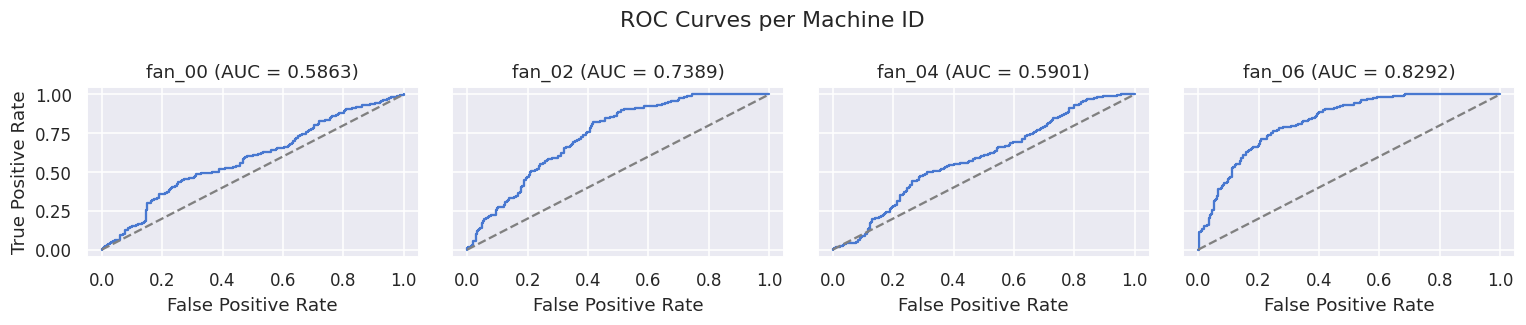

In [ ]:
fig , axes = plt.subplots(1,4,figsize=(14,3),sharey=True)
fig.suptitle('ROC Curves per Machine ID')

for ax ,id in zip(axes,MACHINE_IDS):
  Train, Test = train_test(machine=MACHINE, id=id, verbosity =0 )
  student, teacher = dino_trainer(Train, pretrain= PRETRAIN ,save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt", verbosity = 0)
  train_feats, _ = extract_features(student.backbone, Train)
  test_feats, test_labels = extract_features(student.backbone, Test)
  mu, cov_inv = fit_gaussian(train_feats)
  scores = mahalanobis_score(test_feats, mu, cov_inv)
  y_true, y_score = test_labels.numpy(), scores.numpy()
  auc = roc_auc_score(y_true, y_score)

  fpr, tpr, _ = roc_curve(y_true, y_score)
  ax.plot(fpr, tpr)
  ax.plot([0, 1], [0, 1], '--', color='gray')
  ax.set_xlabel("False Positive Rate")
  if ax is axes[0]:
    ax.set_ylabel("True Positive Rate")
  ax.set_title(f"{MACHINE}_{id:02d} (AUC = {auc:.4f})")

plt.tight_layout()
plt.show()

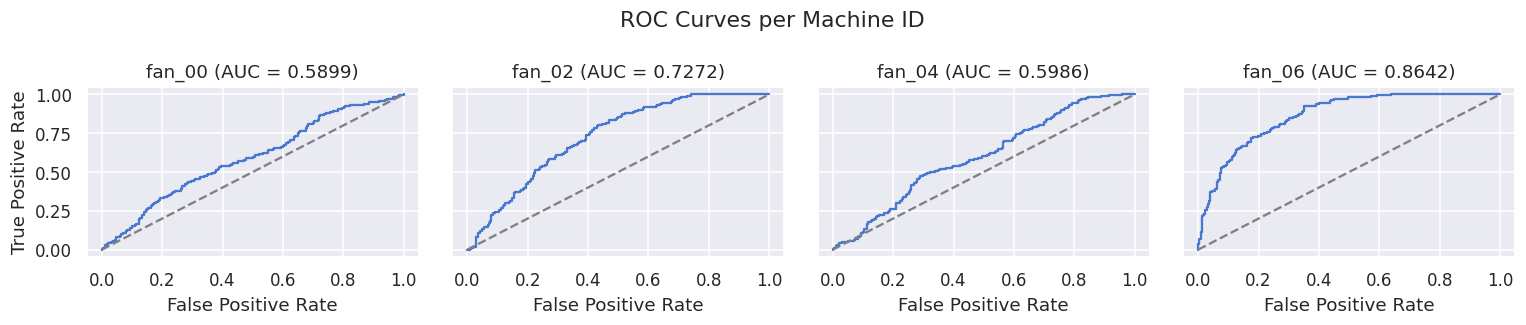

In [ ]:
fig , axes = plt.subplots(1,4,figsize=(14,3),sharey=True)
fig.suptitle('ROC Curves per Machine ID')

for ax ,id in zip(axes,MACHINE_IDS):
  Train, Test = train_test(machine=MACHINE, id=id, verbosity =0 )
  student, teacher = dino_trainer(Train, pretrain= PRETRAIN ,save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_augs_{MACHINE}_{id:02d}_student.pt", verbosity = 0)
  train_feats, _ = extract_features(student.backbone, Train)
  test_feats, test_labels = extract_features(student.backbone, Test)
  mu, cov_inv = fit_gaussian(train_feats)
  scores = mahalanobis_score(test_feats, mu, cov_inv)
  y_true, y_score = test_labels.numpy(), scores.numpy()
  auc = roc_auc_score(y_true, y_score)

  fpr, tpr, _ = roc_curve(y_true, y_score)
  ax.plot(fpr, tpr)
  ax.plot([0, 1], [0, 1], '--', color='gray')
  ax.set_xlabel("False Positive Rate")
  if ax is axes[0]:
    ax.set_ylabel("True Positive Rate")
  ax.set_title(f"{MACHINE}_{id:02d} (AUC = {auc:.4f})")

plt.tight_layout()
plt.show()

Computing t-SNE for 00 (this may take a moment)... status: processing
Computing t-SNE for 02 (this may take a moment)... status: processing
Computing t-SNE for 04 (this may take a moment)... status: processing
Computing t-SNE for 06 (this may take a moment)... status: processing


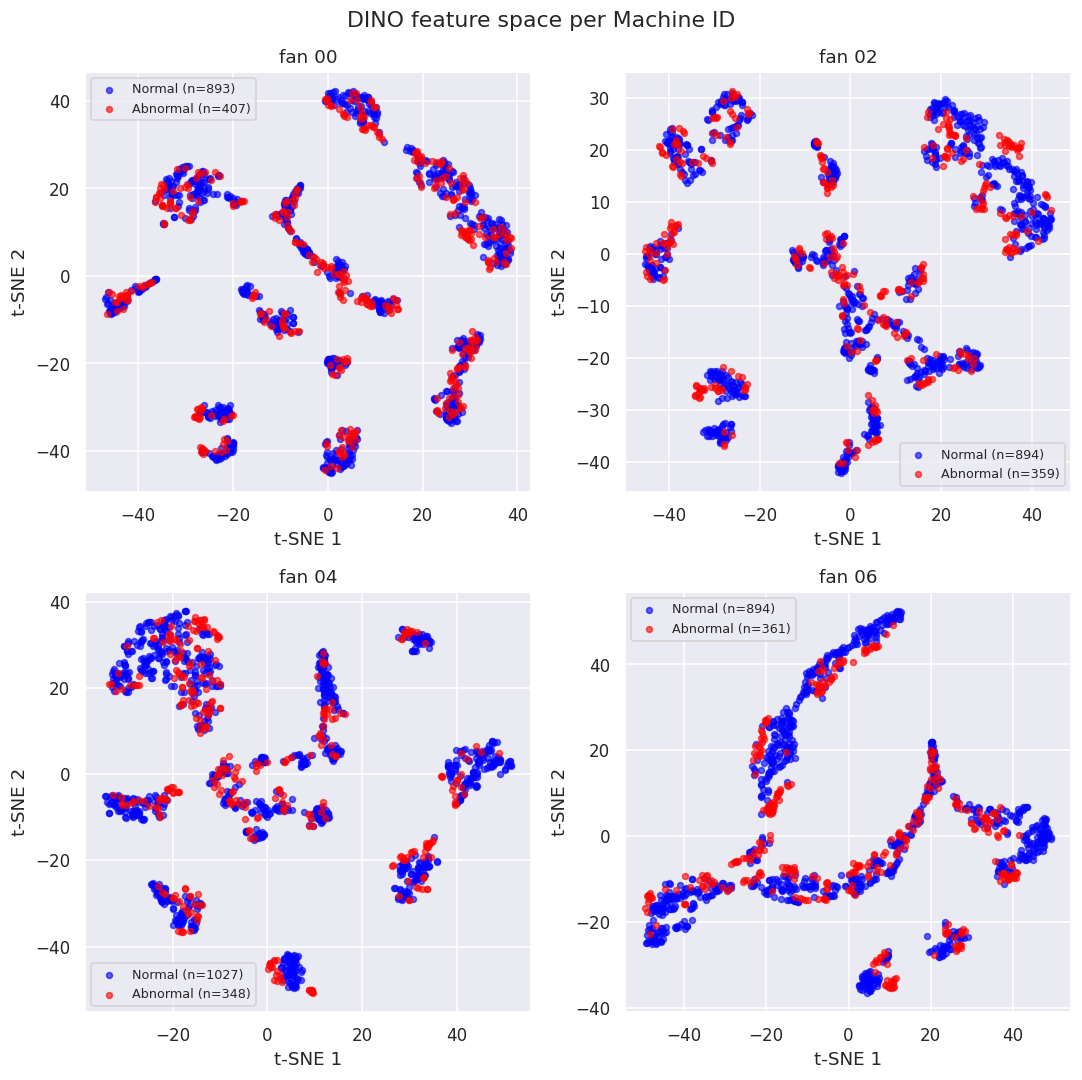

In [ ]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=False)
fig.suptitle('DINO feature space per Machine ID')

# Flatten axes to 1D array for easier iteration in the loop
for ax, id in zip(axes.flatten(), MACHINE_IDS):
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)
    student, teacher = dino_trainer(Train, pretrain=PRETRAIN,
                                    save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_{MACHINE}_{id:02d}_student.pt",
                                    verbosity=0)

    # Extract features for this specific machine ID
    train_feats, _ = extract_features(student.backbone, Train)
    test_feats, test_labels = extract_features(student.backbone, Test)

    # Combine train (all normal) and test features for joint visualization
    all_feats = torch.cat([train_feats, test_feats])
    all_labels = torch.cat([
        torch.zeros(train_feats.shape[0]),
        test_labels
    ])

    # t-SNE projection to 2D
    print(f"Computing t-SNE for {id:02d} (this may take a moment)... status: processing")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    feats_2d = tsne.fit_transform(all_feats.numpy())

    # Separate by label for plotting
    normal_mask = all_labels == 0
    abnormal_mask = all_labels == 1

    ax.scatter(feats_2d[normal_mask, 0], feats_2d[normal_mask, 1],
               alpha=0.6, s=15, label=f'Normal (n={normal_mask.sum()})', color='blue')
    ax.scatter(feats_2d[abnormal_mask, 0], feats_2d[abnormal_mask, 1],
               alpha=0.6, s=15, label=f'Abnormal (n={abnormal_mask.sum()})', color='red')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"{MACHINE} {id:02d}")
    ax.legend(fontsize='x-small')

plt.tight_layout()
plt.show()

Computing t-SNE for 00 (this may take a moment)... status: processing
Computing t-SNE for 02 (this may take a moment)... status: processing
Computing t-SNE for 04 (this may take a moment)... status: processing
Computing t-SNE for 06 (this may take a moment)... status: processing


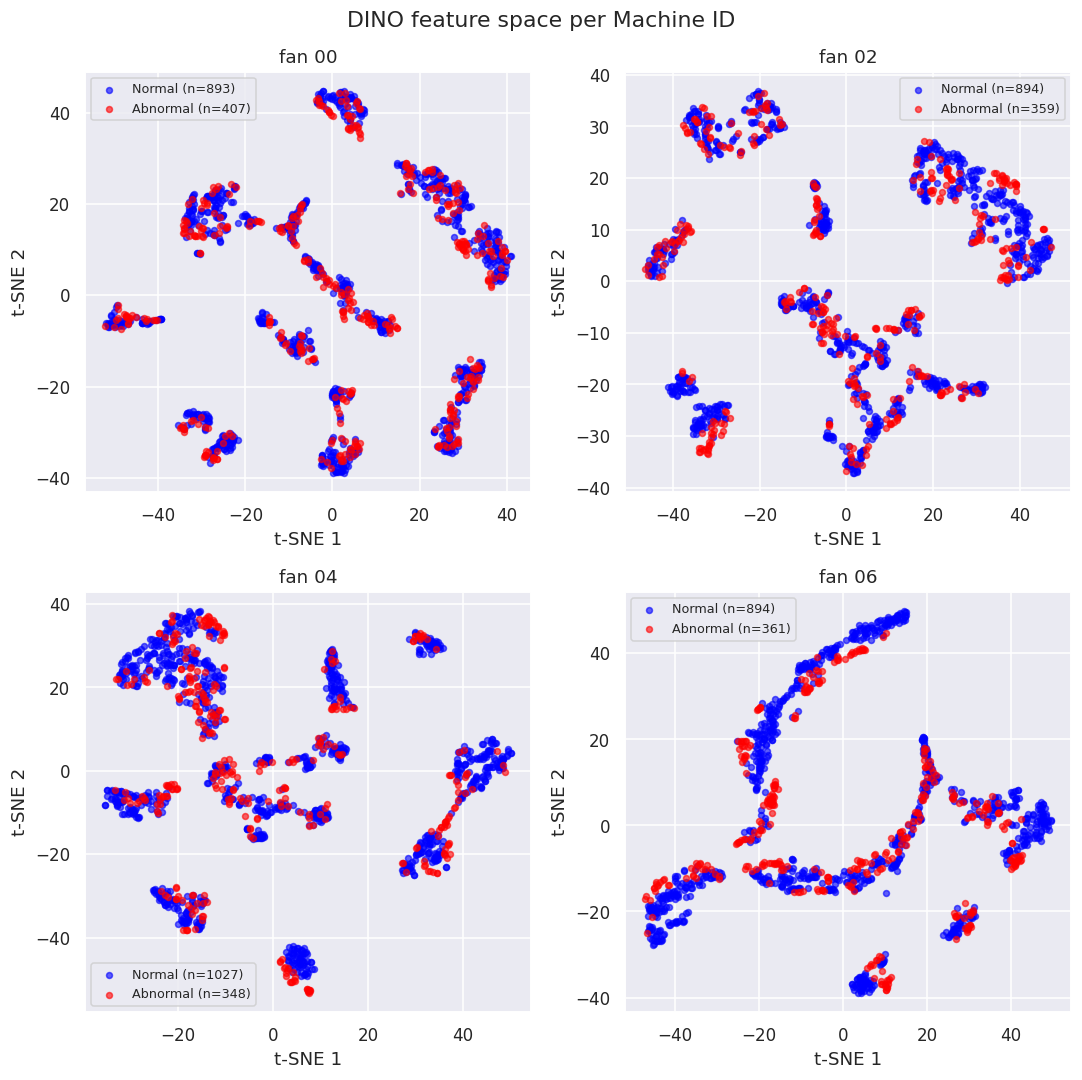

In [ ]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=False)
fig.suptitle('DINO feature space per Machine ID')

# Flatten axes to 1D array for easier iteration in the loop
for ax, id in zip(axes.flatten(), MACHINE_IDS):
    Train, Test = train_test(machine=MACHINE, id=id, verbosity=0)
    student, teacher = dino_trainer(Train, pretrain=PRETRAIN,
                                    save_path=f"/content/drive/MyDrive/ASD-with-SSL/dino_augs_{MACHINE}_{id:02d}_student.pt",
                                    verbosity=0)

    # Extract features for this specific machine ID
    train_feats, _ = extract_features(student.backbone, Train)
    test_feats, test_labels = extract_features(student.backbone, Test)

    # Combine train (all normal) and test features for joint visualization
    all_feats = torch.cat([train_feats, test_feats])
    all_labels = torch.cat([
        torch.zeros(train_feats.shape[0]),
        test_labels
    ])

    # t-SNE projection to 2D
    print(f"Computing t-SNE for {id:02d} (this may take a moment)... status: processing")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
    feats_2d = tsne.fit_transform(all_feats.numpy())

    # Separate by label for plotting
    normal_mask = all_labels == 0
    abnormal_mask = all_labels == 1

    ax.scatter(feats_2d[normal_mask, 0], feats_2d[normal_mask, 1],
               alpha=0.6, s=15, label=f'Normal (n={normal_mask.sum()})', color='blue')
    ax.scatter(feats_2d[abnormal_mask, 0], feats_2d[abnormal_mask, 1],
               alpha=0.6, s=15, label=f'Abnormal (n={abnormal_mask.sum()})', color='red')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.set_title(f"{MACHINE} {id:02d}")
    ax.legend(fontsize='x-small')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import runtime
runtime.unassign()